In [1]:
import numpy as np
import h5py
import gzip
import shutil
import os
import glob

DATA_DIR = "/home/daq/daq-standalone/data/"
TMP_H5 = "/tmp/tmp_calib.h5"

CHANNELS = range(8)
NSAMPLES = 1024

def load_events(filename):
    """Ritorna array shape (Nevents, Nchannels, NSAMPLES)"""
    with gzip.open(filename, 'rb') as f_in:
        with open(TMP_H5, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

    with h5py.File(TMP_H5, 'r') as f:
        events = f["/events"]
        keys = sorted(events.keys(), key=lambda k: int(k.replace("event", "")))

        data = []
        for k in keys:
            wf = np.array(events[k], dtype=np.float64)
            wf = wf.reshape((-1, NSAMPLES))  # [ch][sample]
            data.append(wf[:8])              # solo ch 0–7

    os.remove(TMP_H5)
    return np.array(data)  # (Nevents, 8, 1024)

# === CARICAMENTO RUN ===

print("→ Loading minus400")
data_m400 = load_events(DATA_DIR + "calib_offset_minus400.h5.gz")

print("→ Loading zero")
data_0 = load_events(DATA_DIR + "calib_offset_zero.h5.gz")

data_p400 = {}
for ch in CHANNELS:
    fname = DATA_DIR + f"calib_offset_plus400_ch{ch}.h5.gz"
    print(f"→ Loading +400 for ch{ch}")
    data_p400[ch] = load_events(fname)

# === MEDIE PER CELLA ===

adc_m400 = np.mean(data_m400, axis=0)   # (8, 1024)
adc_0    = np.mean(data_0, axis=0)      # (8, 1024)

adc_p400 = np.zeros((8, NSAMPLES))
for ch in CHANNELS:
    adc_p400[ch] = np.mean(data_p400[ch][:, ch, :], axis=0)

# === OFFSET E SLOPE ===

offset = adc_0.copy()  # ADC a 0V

slope = (adc_p400 - adc_m400) / 800.0  # ADC / mV

# === CONTROLLI DI QUALITÀ ===

print("\n=== CHECK ===")
for ch in CHANNELS:
    print(f"ch{ch}: slope mean = {np.mean(slope[ch]):.4f} ADC/mV, "
          f"std = {np.std(slope[ch]):.4f}")

# === SALVATAGGIO ===

np.savez(
    "drs4_calib_ch0-7.npz",
    offset=offset,
    slope=slope
)

print("\n✔ Calibrazione salvata in drs4_calib_ch0-7.npz")


→ Loading minus400
→ Loading zero
→ Loading +400 for ch0
→ Loading +400 for ch1
→ Loading +400 for ch2
→ Loading +400 for ch3
→ Loading +400 for ch4
→ Loading +400 for ch5
→ Loading +400 for ch6
→ Loading +400 for ch7

=== CHECK ===
ch0: slope mean = 3.4700 ADC/mV, std = 0.0049
ch1: slope mean = 3.4563 ADC/mV, std = 0.0049
ch2: slope mean = 3.4439 ADC/mV, std = 0.0049
ch3: slope mean = 3.5073 ADC/mV, std = 0.0048
ch4: slope mean = 3.4785 ADC/mV, std = 0.0049
ch5: slope mean = 3.4842 ADC/mV, std = 0.0047
ch6: slope mean = 3.4104 ADC/mV, std = 0.0046
ch7: slope mean = 3.3854 ADC/mV, std = 0.0045

✔ Calibrazione salvata in drs4_calib_ch0-7.npz


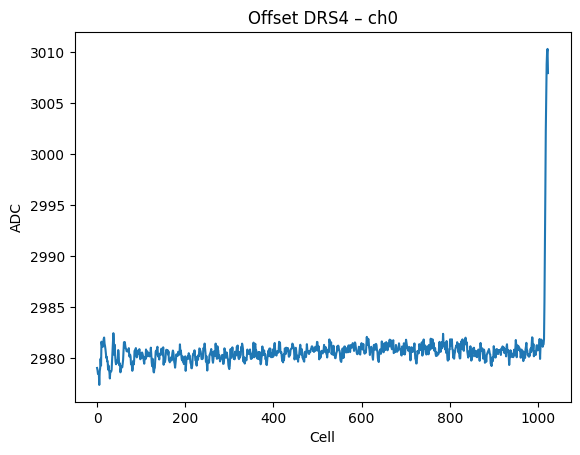

In [2]:
import matplotlib.pyplot as plt
plt.plot(offset[2])
plt.title("Offset DRS4 – ch0")
plt.xlabel("Cell")
plt.ylabel("ADC")
plt.show()